In [1]:
filename = "house_pricing_data.csv"
target_variable_name = "price"

In [16]:
from pyspark.sql.functions import *

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
data = spark.read.csv(filename, header=True, inferSchema=True, sep=',')
data.show()

+------------+-------------+-------+-------+------+--------+-------------+-------------+----+----------+-----------------+--------+-----+------+--------------+------------+---------+--------+
|squareMeters|numberOfRooms|hasYard|hasPool|floors|cityCode|cityPartRange|numPrevOwners|made|isNewBuilt|hasStormProtector|basement|attic|garage|hasStorageRoom|hasGuestRoom|    price|category|
+------------+-------------+-------+-------+------+--------+-------------+-------------+----+----------+-----------------+--------+-----+------+--------------+------------+---------+--------+
|       75523|            3|     No|    Yes|    63|    9373|            3|            8|2005|        No|              Yes|    4313| 9005|   956|            No|           7|7559081.5|   Basic|
|       80771|           39|    Yes|    Yes|    98|   39381|            8|            6|2015|       Yes|               No|    3653| 2436|   128|           Yes|           2|8085989.5|  Luxury|
|       55712|           58|     No|    

# EDA

## Basic Statistics

In [3]:
data.count()

10000

In [4]:
data.describe().toPandas()

,summary,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,category
0,count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,9993,10000,10000,10000,10000
1,mean,49870.1312,50.3584,None,None,50.2763,50225.4861,5.5101,5.5217,2005.4885,None,None,5033.1039,5028.0106,553.1385970179125,None,4.9946,4993447.525749963,None
2,stddev,28774.37535029503,28.81669636927458,None,None,28.88917127111252,29006.675799293178,2.87202417160515,2.8566667927002753,9.308089589340009,None,None,2876.7295448116365,2894.3322098165813,262.00826698768293,None,3.1764098913678978,2877424.109945015,None
3,min,89,1,No,No,1,3,1,1,1990,No,No,0,1,100,No,0,10313.5,Basic
4,max,99999,100,Yes,Yes,100,99953,10,10,2021,Yes,Yes,10000,10000,1000,Yes,10,1.00067712E7,Luxury


In [5]:
data.dtypes

[('squareMeters', 'int'),
 ('numberOfRooms', 'int'),
 ('hasYard', 'string'),
 ('hasPool', 'string'),
 ('floors', 'int'),
 ('cityCode', 'int'),
 ('cityPartRange', 'int'),
 ('numPrevOwners', 'int'),
 ('made', 'int'),
 ('isNewBuilt', 'string'),
 ('hasStormProtector', 'string'),
 ('basement', 'int'),
 ('attic', 'int'),
 ('garage', 'int'),
 ('hasStorageRoom', 'string'),
 ('hasGuestRoom', 'int'),
 ('price', 'double'),
 ('category', 'string')]

In [6]:
data.printSchema()

root
 |-- squareMeters: integer (nullable = true)
 |-- numberOfRooms: integer (nullable = true)
 |-- hasYard: string (nullable = true)
 |-- hasPool: string (nullable = true)
 |-- floors: integer (nullable = true)
 |-- cityCode: integer (nullable = true)
 |-- cityPartRange: integer (nullable = true)
 |-- numPrevOwners: integer (nullable = true)
 |-- made: integer (nullable = true)
 |-- isNewBuilt: string (nullable = true)
 |-- hasStormProtector: string (nullable = true)
 |-- basement: integer (nullable = true)
 |-- attic: integer (nullable = true)
 |-- garage: integer (nullable = true)
 |-- hasStorageRoom: string (nullable = true)
 |-- hasGuestRoom: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- category: string (nullable = true)



## Check for Missing Value

In [7]:
data.toPandas().isnull().sum()

squareMeters         0
numberOfRooms        0
hasYard              0
hasPool              0
floors               0
cityCode             0
cityPartRange        0
numPrevOwners        0
made                 0
isNewBuilt           0
hasStormProtector    0
basement             0
attic                0
garage               7
hasStorageRoom       0
hasGuestRoom         0
price                0
category             0
dtype: int64

## Check for Cardinality

In [8]:
data.toPandas().nunique()

squareMeters          9483
numberOfRooms          100
hasYard                  2
hasPool                  2
floors                 100
cityCode              9509
cityPartRange           10
numPrevOwners           10
made                    32
isNewBuilt               2
hasStormProtector        2
basement              6352
attic                 6267
garage                 901
hasStorageRoom           2
hasGuestRoom            11
price                10000
category                 2
dtype: int64

## Data Cleaning and Preparation

### Change Missing Value to Mean

In [17]:
for column in data.columns:
    mean_value = data.select(mean(col(column)).alias('mean')).collect()[0]["mean"]
    mode_value = data.select(mode(col(column)).alias('mode')).collect()[0]['mode']
    if mean_value is not None:
        data = data.na.fill(mean_value, [column])
    else :
        data = data.na.fill(mode_value, [column])

In [18]:
data.toPandas().isnull().sum()

squareMeters         0
numberOfRooms        0
hasYard              0
hasPool              0
floors               0
cityCode             0
cityPartRange        0
numPrevOwners        0
made                 0
isNewBuilt           0
hasStormProtector    0
basement             0
attic                0
garage               0
hasStorageRoom       0
hasGuestRoom         0
price                0
category             0
dtype: int64

## Label Encoding

In [19]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.types import StringType

def index_string_columns(df):
    string_columns = [t[0] for t in df.dtypes if t[1] == 'string']
    for column in string_columns:
        indexer = StringIndexer(inputCol=column, outputCol=column+"_index")
        df = indexer.fit(df).transform(df)
    return df

In [20]:
data = index_string_columns(data)

In [21]:
data.dtypes

[('squareMeters', 'int'),
 ('numberOfRooms', 'int'),
 ('hasYard', 'string'),
 ('hasPool', 'string'),
 ('floors', 'int'),
 ('cityCode', 'int'),
 ('cityPartRange', 'int'),
 ('numPrevOwners', 'int'),
 ('made', 'int'),
 ('isNewBuilt', 'string'),
 ('hasStormProtector', 'string'),
 ('basement', 'int'),
 ('attic', 'int'),
 ('garage', 'int'),
 ('hasStorageRoom', 'string'),
 ('hasGuestRoom', 'int'),
 ('price', 'double'),
 ('category', 'string'),
 ('hasYard_index', 'double'),
 ('hasPool_index', 'double'),
 ('isNewBuilt_index', 'double'),
 ('hasStormProtector_index', 'double'),
 ('hasStorageRoom_index', 'double'),
 ('category_index', 'double')]

### Drop all String/Object Variables

In [22]:
def variable_type(df):
    
    vars_list = df.dtypes
    char_vars = []
    num_vars = []
    for i in vars_list:
        if i[1] in ('string'):
            char_vars.append(i[0])
        else:
            num_vars.append(i[0])
    
    return char_vars, num_vars

In [23]:
char_vars, num_vars = variable_type(data)

data = data.select([c for c in data.columns if c not in char_vars])

In [24]:
data.printSchema()

root
 |-- squareMeters: integer (nullable = true)
 |-- numberOfRooms: integer (nullable = true)
 |-- floors: integer (nullable = true)
 |-- cityCode: integer (nullable = true)
 |-- cityPartRange: integer (nullable = true)
 |-- numPrevOwners: integer (nullable = true)
 |-- made: integer (nullable = true)
 |-- basement: integer (nullable = true)
 |-- attic: integer (nullable = true)
 |-- garage: integer (nullable = true)
 |-- hasGuestRoom: integer (nullable = true)
 |-- price: double (nullable = false)
 |-- hasYard_index: double (nullable = false)
 |-- hasPool_index: double (nullable = false)
 |-- isNewBuilt_index: double (nullable = false)
 |-- hasStormProtector_index: double (nullable = false)
 |-- hasStorageRoom_index: double (nullable = false)
 |-- category_index: double (nullable = false)



## Visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Check for Normality

In [10]:
sns.histplot(data.toPandas())

### Check for Correlation

<Axes: >

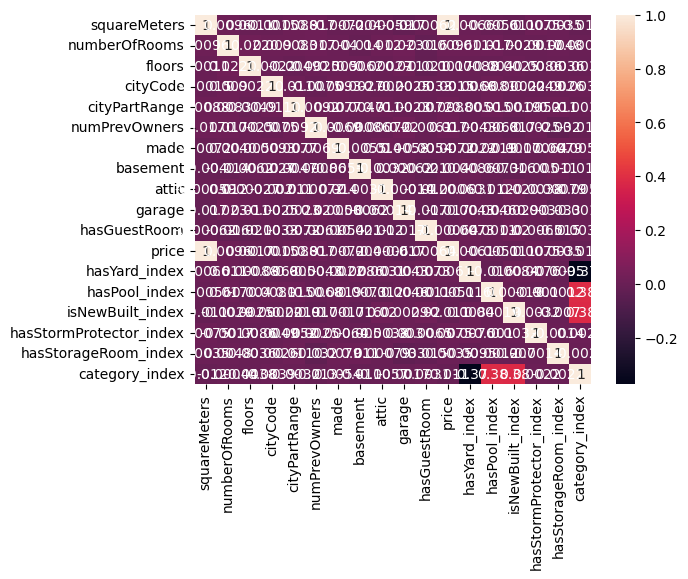

In [25]:
sns.heatmap(data.toPandas().corr(), annot=True)

From the Heatmap Above we can see that price is only correlated to squareMeters

# Model Data Preparation

### Dropping Useless/Uncorrelated Features

In [26]:
data = data['price', 'squareMeters']

In [27]:
data.show(5)

+---------+------------+
|    price|squareMeters|
+---------+------------+
|7559081.5|       75523|
|8085989.5|       80771|
|5574642.1|       55712|
|3232561.2|       32316|
|7055052.0|       70429|
+---------+------------+
only showing top 5 rows



### Split Data

In [28]:
train, test = data.randomSplit([0.7, 0.3], seed=12345)

In [29]:
#exclude target variable and select all other feature vectors
features_list = data.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)

In [30]:
features_list

['squareMeters']

### Vector Assembling

In [31]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features'] + features_list
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

In [44]:
df_assemble = assemble_vectors(train, features_list, target_variable_name)
df_test_assemble = assemble_vectors(test, features_list, target_variable_name)

In [45]:
df_assemble.show(5)

+-------+--------+------------+
|  price|features|squareMeters|
+-------+--------+------------+
|10313.5|  [89.0]|          89|
|13229.1| [123.0]|         123|
|14431.3| [111.0]|         111|
|15488.0| [128.0]|         128|
|16799.2| [148.0]|         148|
+-------+--------+------------+
only showing top 5 rows



# Modelling

## Linear Regression

In [35]:
from pyspark.ml.regression import LinearRegression
reg = LinearRegression(featuresCol='features', labelCol='price')
reg_model = reg.fit(df_assemble) # fit model

In [36]:
# Initialize a list to hold DataFrames
dfs = []

for k, v in df_assemble.schema["features"].metadata["ml_attr"]["attrs"].items():
    # Convert each dictionary in v to a DataFrame and add it to the list
    dfs.append(pd.DataFrame(v))

# Concatenate all the DataFrames in the list
features_df = pd.concat(dfs, ignore_index=True)

# print coefficient and intercept
print(reg_model.coefficients, reg_model.intercept)

features_df['coefficients'] = reg_model.coefficients

[99.99864412072328] 6483.071831549276


In [37]:
features_df

,idx,name,coefficients
0,0,squareMeters,99.998644


In [46]:
#prediction result
pred_result = reg_model.transform(df_test_assemble)

### RMSE Evaluation Evaluation

In [57]:
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize evaluator
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")

# Compute Root Mean Square Error (RMSE) on test data
rmse = evaluator_rmse.evaluate(pred_result)
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

Root Mean Squared Error (RMSE) on test data = 3299.5


### r2 Evaluation Evaluation

In [59]:
# Initialize evaluator
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

# Compute Root Mean Square Error (RMSE) on test data
r2 = evaluator_rmse.evaluate(pred_result)
print("R2 Score on test data = %g" % r2)

R2 Score on test data = 0.999999


## Decission Tree Regression

In [40]:
from pyspark.ml.regression import DecisionTreeRegressor
dtreg = DecisionTreeRegressor(featuresCol='features', labelCol='price')
dt_reg_model = dtreg.fit(df_assemble) # fit model

In [48]:
#prediction result
dt_pred_result = dt_reg_model.transform(df_test_assemble)

### RMSE Evaluation Evaluation

In [61]:
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize evaluator
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")

# Compute Root Mean Square Error (RMSE) on test data
rmse = evaluator_rmse.evaluate(dt_pred_result)
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

Root Mean Squared Error (RMSE) on test data = 91148


### r2 Evaluation Evaluation

In [63]:
# Initialize evaluator
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

# Compute Root Mean Square Error (RMSE) on test data
r2 = evaluator_rmse.evaluate(dt_pred_result)
print("R2 Score on test data = %g" % r2)

R2 Score on test data = 0.998992
